In [4]:
"""EDA-скрипт для проекта Titanic.

В этом файле находится ТОЛЬКО разведочный анализ данных (EDA):
- загрузка исходных train/test данных;
- проверка структуры датасета и пропусков;
- анализ целевой переменной Survived;
- анализ связи выживаемости с Sex, Pclass, Embarked, Age, Fare, FamilySize;
- легкий feature engineering только для аналитики.

"""

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Единый стиль графиков, чтобы все визуализации выглядели аккуратно.
sns.set_theme(style="whitegrid", context="notebook")

# Ожидаемая структура проекта из report:
# data/raw/train.csv
# data/raw/test.csv
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"
TEST_PATH = PROJECT_ROOT / "data" / "raw" / "test.csv"

# Запасной вариант: если скрипт/ноутбук лежит рядом с CSV-файлами.
if not TRAIN_PATH.exists():
    TRAIN_PATH = PROJECT_ROOT / "train.csv"
if not TEST_PATH.exists():
    TEST_PATH = PROJECT_ROOT / "test.csv"

# Загружаем исходные данные. В EDA мы не меняем raw-файлы на диске.
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Размер train:", train_df.shape)
print("Размер test:", test_df.shape)
display(train_df.head())
display(test_df.head())

Размер train: (891, 12)
Размер test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 2. Базовая информация о датасете

In [5]:
# Базовая информация о датасете: колонки, типы данных и описательные статистики.
print("Колонки train:")
print(train_df.columns.tolist())

print("\nТипы данных в train:")
display(train_df.dtypes.to_frame("тип_данных"))

print("\nОписательные статистики train:")
display(train_df.describe(include="all").T)

Колонки train:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Типы данных в train:


,тип_данных
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Описательные статистики train:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 3. Проверка пропусков

In [6]:
# Аудит пропусков: смотрим, где и сколько данных отсутствует.
missing_train = (
    train_df.isna().sum()
    .to_frame("количество_пропусков")
    .assign(процент_пропусков=lambda x: x["количество_пропусков"] / len(train_df) * 100)
    .sort_values("количество_пропусков", ascending=False)
)

missing_test = (
    test_df.isna().sum()
    .to_frame("количество_пропусков")
    .assign(процент_пропусков=lambda x: x["количество_пропусков"] / len(test_df) * 100)
    .sort_values("количество_пропусков", ascending=False)
)

print("Пропуски в train:")
display(missing_train)

print("Пропуски в test:")
display(missing_test)

Пропуски в train:


,количество_пропусков,процент_пропусков
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


Пропуски в test:


,количество_пропусков,процент_пропусков
Cabin,327,78.229665
Age,86,20.574163
Fare,1,0.239234
Name,0,0.000000
Pclass,0,0.000000
PassengerId,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000
Ticket,0,0.000000


## 4. Распределение целевой переменной

Общая доля выживших: 0.384


,количество
Survived,
0,549
1,342


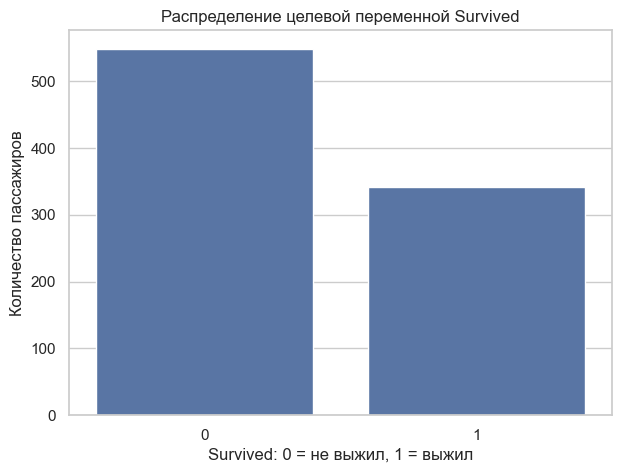

In [7]:
# Распределение целевой переменной Survived.
# 0 — пассажир не выжил, 1 — пассажир выжил.
survival_counts = train_df["Survived"].value_counts().sort_index()
survival_rate = train_df["Survived"].mean()

print(f"Общая доля выживших: {survival_rate:.3f}")
display(survival_counts.to_frame("количество"))

plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x="Survived")
plt.title("Распределение целевой переменной Survived")
plt.xlabel("Survived: 0 = не выжил, 1 = выжил")
plt.ylabel("Количество пассажиров")
plt.show()

## 5. Выживаемость по полу

,Sex,пассажиров,доля_выживших
0,female,314,0.742038
1,male,577,0.188908


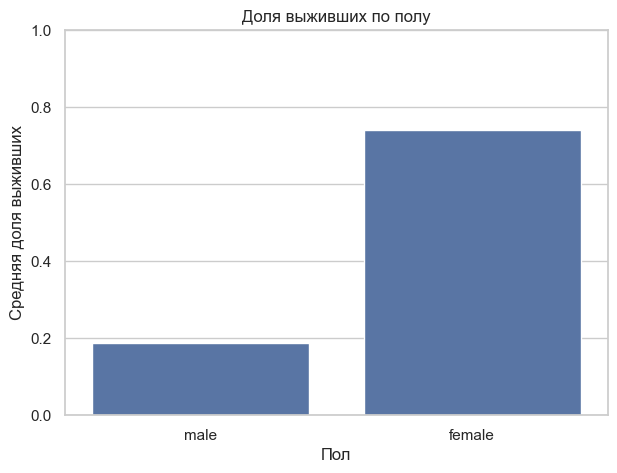

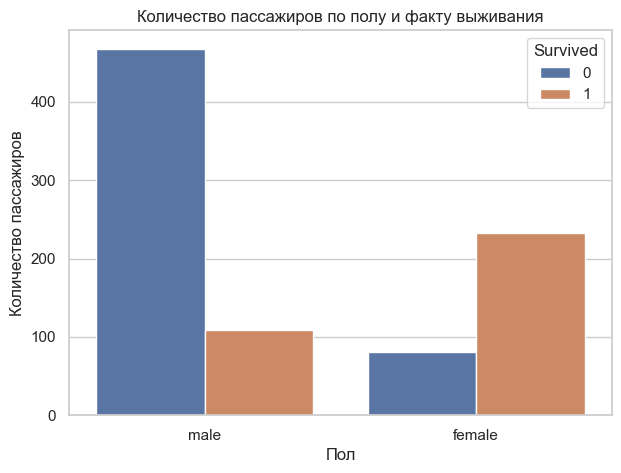

In [8]:
# Анализ выживаемости по полу.
sex_survival = (
    train_df.groupby("Sex", as_index=False)
    .agg(пассажиров=("Survived", "size"), доля_выживших=("Survived", "mean"))
    .sort_values("доля_выживших", ascending=False)
)

display(sex_survival)

plt.figure(figsize=(7, 5))
sns.barplot(data=train_df, x="Sex", y="Survived", errorbar=None)
plt.title("Доля выживших по полу")
plt.xlabel("Пол")
plt.ylabel("Средняя доля выживших")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x="Sex", hue="Survived")
plt.title("Количество пассажиров по полу и факту выживания")
plt.xlabel("Пол")
plt.ylabel("Количество пассажиров")
plt.show()

## 6. Выживаемость по классу билета

,Pclass,пассажиров,доля_выживших
0,1,216,0.629630
1,2,184,0.472826
2,3,491,0.242363


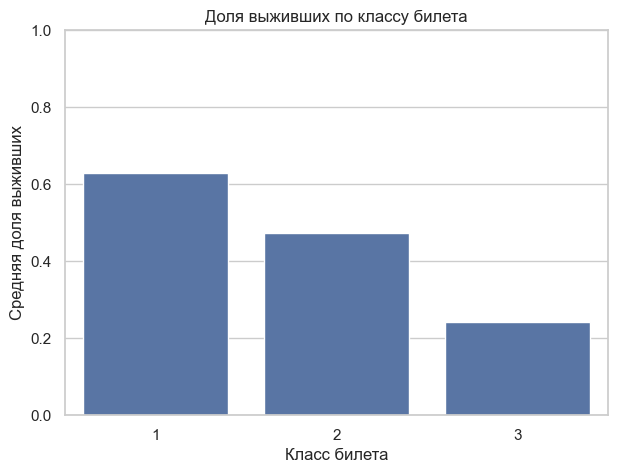

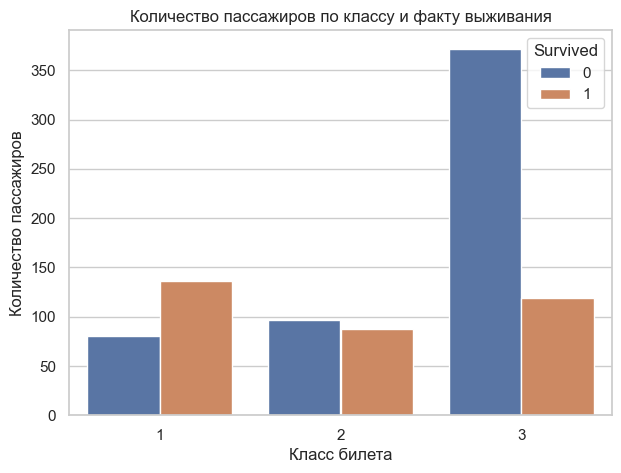

In [9]:
# Анализ выживаемости по классу билета.
class_survival = (
    train_df.groupby("Pclass", as_index=False)
    .agg(пассажиров=("Survived", "size"), доля_выживших=("Survived", "mean"))
    .sort_values("Pclass")
)

display(class_survival)

plt.figure(figsize=(7, 5))
sns.barplot(data=train_df, x="Pclass", y="Survived", errorbar=None)
plt.title("Доля выживших по классу билета")
plt.xlabel("Класс билета")
plt.ylabel("Средняя доля выживших")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x="Pclass", hue="Survived")
plt.title("Количество пассажиров по классу и факту выживания")
plt.xlabel("Класс билета")
plt.ylabel("Количество пассажиров")
plt.show()

## 7. Совместное влияние пола и класса

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


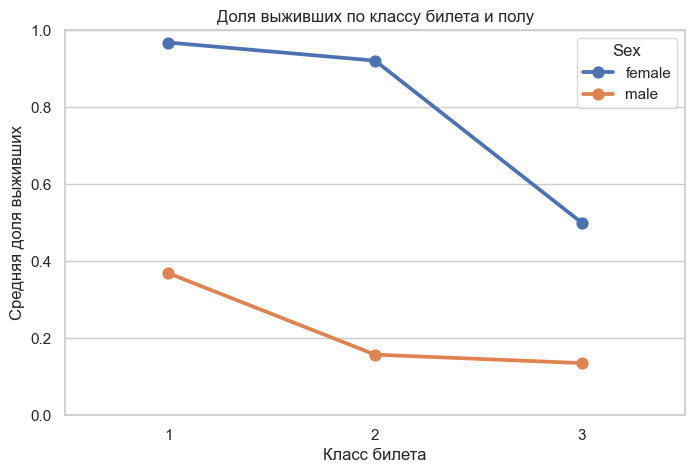

In [10]:
# Взаимодействие пола и класса билета.
# Это важный блок: вместе Sex и Pclass часто объясняют выживаемость сильнее, чем по отдельности.
sex_class_survival = train_df.pivot_table(
    index="Pclass",
    columns="Sex",
    values="Survived",
    aggfunc="mean",
)

display(sex_class_survival)

plt.figure(figsize=(8, 5))
sns.pointplot(data=train_df, x="Pclass", y="Survived", hue="Sex", errorbar=None)
plt.title("Доля выживших по классу билета и полу")
plt.xlabel("Класс билета")
plt.ylabel("Средняя доля выживших")
plt.ylim(0, 1)
plt.show()

## 8. Анализ порта посадки

,Embarked,пассажиров,доля_выживших
1,Missing,2,1.000000
0,C,168,0.553571
2,Q,77,0.389610
3,S,644,0.336957


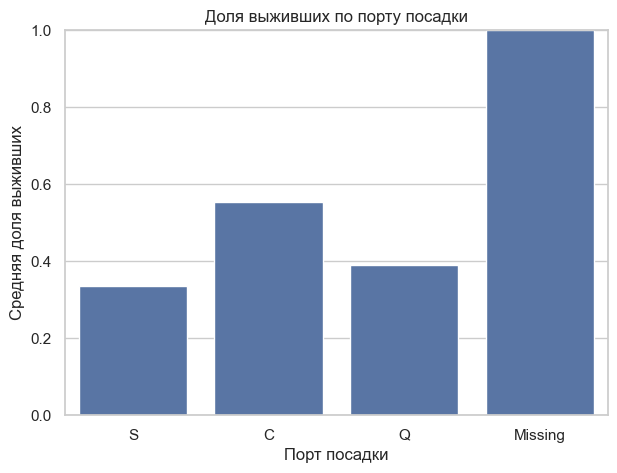

In [11]:
# Анализ порта посадки Embarked.
# Пропуски временно помечаем как Missing только для EDA.
embarked_df = train_df.copy()
embarked_df["Embarked"] = embarked_df["Embarked"].fillna("Missing")

embarked_survival = (
    embarked_df.groupby("Embarked", as_index=False)
    .agg(пассажиров=("Survived", "size"), доля_выживших=("Survived", "mean"))
    .sort_values("доля_выживших", ascending=False)
)

display(embarked_survival)

plt.figure(figsize=(7, 5))
sns.barplot(data=embarked_df, x="Embarked", y="Survived", errorbar=None)
plt.title("Доля выживших по порту посадки")
plt.xlabel("Порт посадки")
plt.ylabel("Средняя доля выживших")
plt.ylim(0, 1)
plt.show()

## 9. Анализ возраста

Статистики по возрасту:


,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


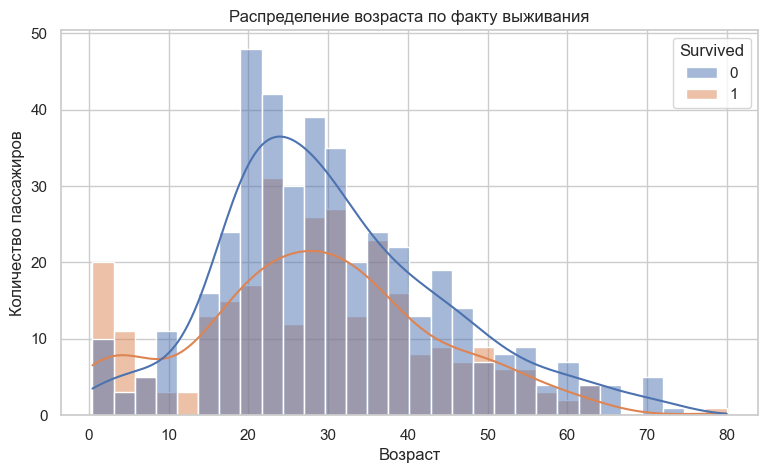

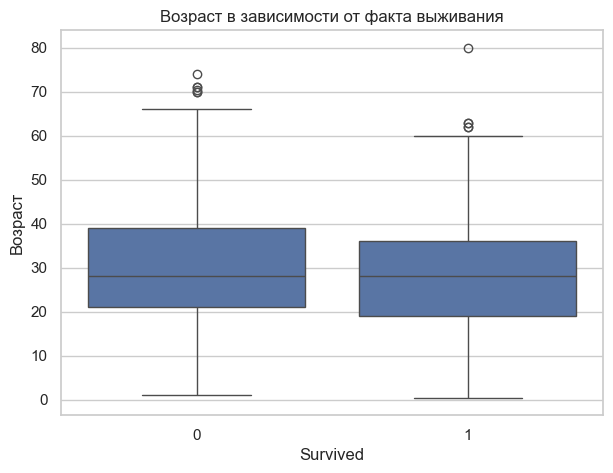

In [12]:
# Анализ возраста.
# Здесь важно увидеть распределение Age, пропуски и возможную связь возраста с Survived.
print("Статистики по возрасту:")
display(train_df["Age"].describe().to_frame("Age"))

plt.figure(figsize=(9, 5))
sns.histplot(data=train_df, x="Age", hue="Survived", bins=30, kde=True, multiple="layer")
plt.title("Распределение возраста по факту выживания")
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=train_df, x="Survived", y="Age")
plt.title("Возраст в зависимости от факта выживания")
plt.xlabel("Survived")
plt.ylabel("Возраст")
plt.show()

## 10. Титул из имени пассажира

,Initial,пассажиров,медианный_возраст,средний_возраст,доля_выживших
2,Mr,529,30.0,32.739609,0.162571
1,Miss,185,21.0,21.845638,0.702703
3,Mrs,128,35.0,35.873874,0.796875
0,Master,40,3.5,4.574167,0.575000
4,Other,9,51.0,45.888889,0.111111


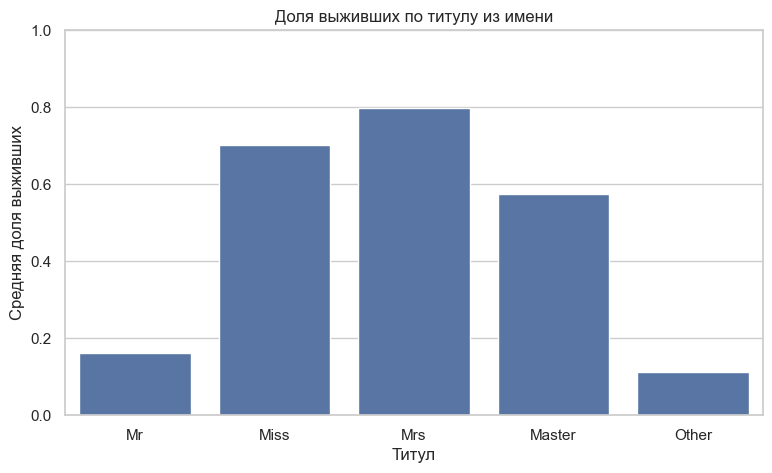

In [13]:
# Извлекаем титул из имени пассажира только для EDA.
# В будущем этот признак можно использовать в feature engineering.
TITLE_MAP = {
    "Mlle": "Miss",
    "Mme": "Mrs",
    "Ms": "Miss",
    "Dr": "Mr",
    "Major": "Mr",
    "Lady": "Mrs",
    "Countess": "Mrs",
    "Jonkheer": "Other",
    "Col": "Other",
    "Rev": "Other",
    "Capt": "Mr",
    "Sir": "Mr",
    "Don": "Mr",
    "Dona": "Mrs",
}

eda_df = train_df.copy()
eda_df["Initial"] = eda_df["Name"].str.extract(r"([A-Za-z]+)\.")
eda_df["Initial"] = eda_df["Initial"].replace(TITLE_MAP)

initial_summary = (
    eda_df.groupby("Initial", as_index=False)
    .agg(
        пассажиров=("Survived", "size"),
        медианный_возраст=("Age", "median"),
        средний_возраст=("Age", "mean"),
        доля_выживших=("Survived", "mean"),
    )
    .sort_values("пассажиров", ascending=False)
)

display(initial_summary)

plt.figure(figsize=(9, 5))
sns.barplot(data=initial_summary, x="Initial", y="доля_выживших", errorbar=None)
plt.title("Доля выживших по титулу из имени")
plt.xlabel("Титул")
plt.ylabel("Средняя доля выживших")
plt.ylim(0, 1)
plt.show()

## 11. Анализ стоимости билета

Статистики по Fare:


,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


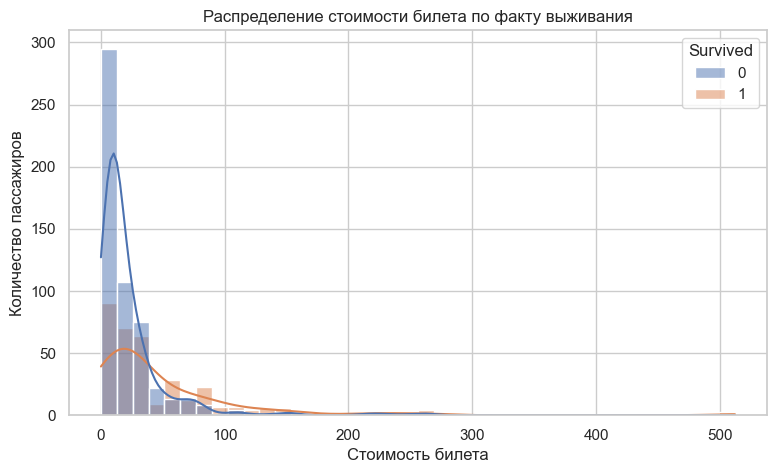

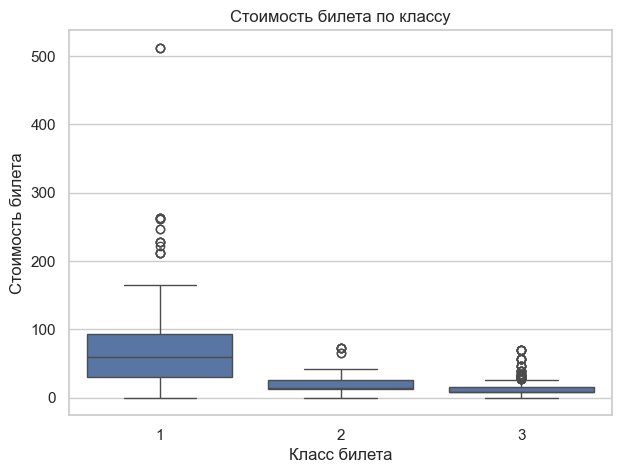

In [14]:
# Анализ стоимости билета Fare.
print("Статистики по Fare:")
display(train_df["Fare"].describe().to_frame("Fare"))

plt.figure(figsize=(9, 5))
sns.histplot(data=train_df, x="Fare", hue="Survived", bins=40, kde=True, multiple="layer")
plt.title("Распределение стоимости билета по факту выживания")
plt.xlabel("Стоимость билета")
plt.ylabel("Количество пассажиров")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=train_df, x="Pclass", y="Fare")
plt.title("Стоимость билета по классу")
plt.xlabel("Класс билета")
plt.ylabel("Стоимость билета")
plt.show()

## 12. Семейные признаки

,FamilySize,пассажиров,доля_выживших
0,1,537,0.303538
1,2,161,0.552795
2,3,102,0.578431
3,4,29,0.724138
4,5,15,0.200000
5,6,22,0.136364
6,7,12,0.333333
7,8,6,0.000000
8,11,7,0.000000


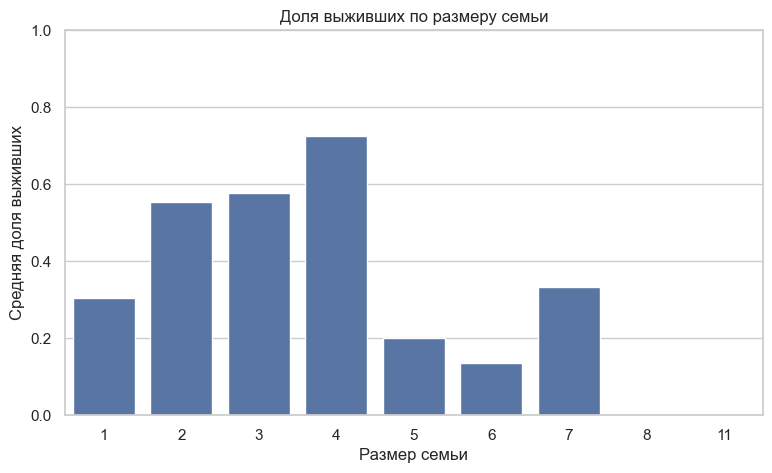

,IsAlone,пассажиров,доля_выживших
0,0,354,0.505650
1,1,537,0.303538


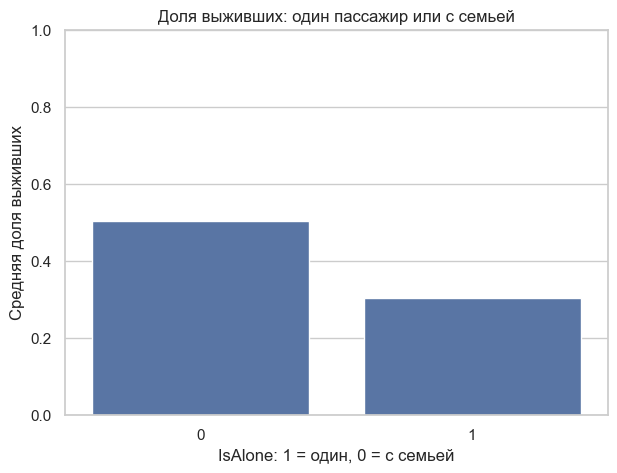

In [15]:
# Семейные признаки только для EDA.
# FamilySize = сам пассажир + супруги/братья/сестры + родители/дети.
eda_df["FamilySize"] = eda_df["SibSp"] + eda_df["Parch"] + 1
eda_df["IsAlone"] = (eda_df["FamilySize"] == 1).astype(int)

family_summary = (
    eda_df.groupby("FamilySize", as_index=False)
    .agg(пассажиров=("Survived", "size"), доля_выживших=("Survived", "mean"))
    .sort_values("FamilySize")
)

display(family_summary)

plt.figure(figsize=(9, 5))
sns.barplot(data=family_summary, x="FamilySize", y="доля_выживших", errorbar=None)
plt.title("Доля выживших по размеру семьи")
plt.xlabel("Размер семьи")
plt.ylabel("Средняя доля выживших")
plt.ylim(0, 1)
plt.show()

alone_summary = (
    eda_df.groupby("IsAlone", as_index=False)
    .agg(пассажиров=("Survived", "size"), доля_выживших=("Survived", "mean"))
)

display(alone_summary)

plt.figure(figsize=(7, 5))
sns.barplot(data=eda_df, x="IsAlone", y="Survived", errorbar=None)
plt.title("Доля выживших: один пассажир или с семьей")
plt.xlabel("IsAlone: 1 = один, 0 = с семьей")
plt.ylabel("Средняя доля выживших")
plt.ylim(0, 1)
plt.show()

## 13. Корреляция числовых признаков

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658,-0.040143,0.057462
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.016639,-0.203367
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.065997,0.135207
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,-0.301914,0.198270
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,0.890712,-0.584471
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,0.783111,-0.583398
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,0.217138,-0.271832
FamilySize,-0.040143,0.016639,0.065997,-0.301914,0.890712,0.783111,0.217138,1.000000,-0.690922
IsAlone,0.057462,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,-0.690922,1.000000


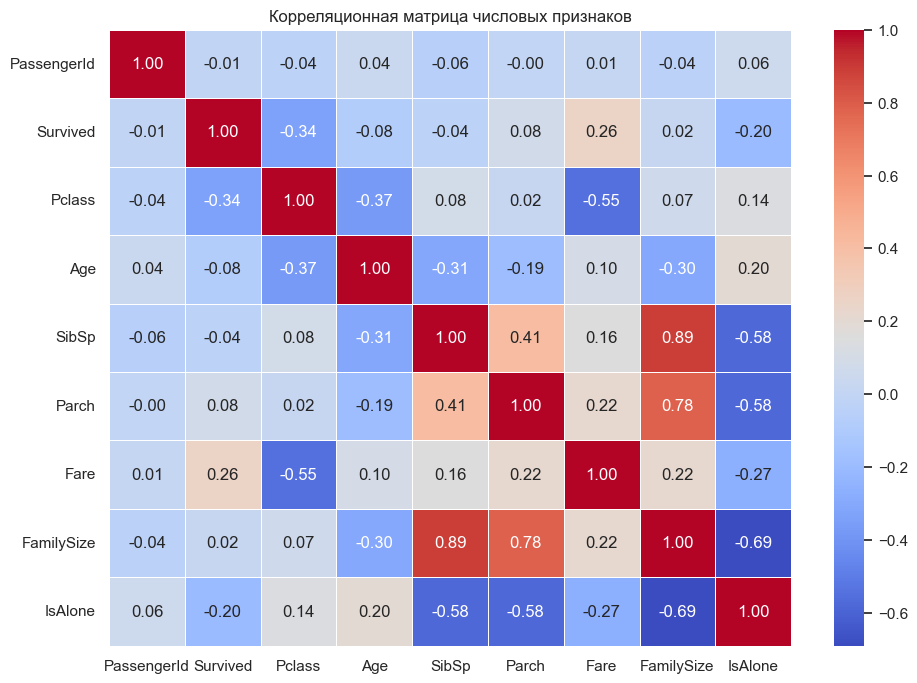

In [16]:
# Корреляция между числовыми признаками.
# Корреляция не доказывает причинность, но помогает увидеть сильные связи между признаками.
numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
correlation = eda_df[numeric_cols].corr()

display(correlation)

plt.figure(figsize=(11, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

## 14. Краткие выводы по EDA

In [17]:
conclusions = pd.DataFrame(
    {
        "блок_анализа": [
            "Целевая переменная",
            "Пол",
            "Класс билета",
            "Пол x класс билета",
            "Возраст",
            "Титул из имени",
            "Стоимость билета",
            "FamilySize / IsAlone",
            "Пропуски",
        ],
        "eda_вывод": [
            "Классы целевой переменной не равны: погибших пассажиров больше, чем выживших.",
            "У женщин доля выживших заметно выше, чем у мужчин.",
            "Чем выше класс билета, тем выше доля выживших.",
            "Пол и класс билета вместе дают сильный паттерн выживаемости.",
            "В Age есть пропуски; возраст нужно аккуратно обработать перед обучением модели.",
            "Титул из Name может быть полезен как приближенный признак возраста и социального статуса.",
            "Fare распределен неравномерно и связан с классом/статусом пассажира.",
            "Размер семьи и факт путешествия в одиночку показывают различия в выживаемости.",
            "Age, Cabin, Embarked в train и Fare/Cabin/Age в test требуют preprocessing.",
        ],
        "идея_для_feature_engineering": [
            "Использовать stratified validation, потому что классы не полностью сбалансированы.",
            "Оставить Sex как важный категориальный признак.",
            "Оставить Pclass как важный порядковый/числовой признак.",
            "Учесть совместное влияние признаков через tree/boosting модели или новые признаки.",
            "Заполнять Age не только общим средним, а статистиками по группам/титулам.",
            "Создать Initial из Name и объединить редкие титулы.",
            "Заполнить пропущенный Fare; при необходимости рассмотреть log-преобразование.",
            "Создать FamilySize и IsAlone.",
            "Применять одинаковую preprocessing-логику к train и test.",
        ],
    }
)

display(conclusions)

,блок_анализа,eda_вывод,идея_для_feature_engineering
0,Целевая переменная,Классы целевой переменной не равны: погибших п...,"Использовать stratified validation, потому что..."
1,Пол,"У женщин доля выживших заметно выше, чем у муж...",Оставить Sex как важный категориальный признак.
2,Класс билета,"Чем выше класс билета, тем выше доля выживших.",Оставить Pclass как важный порядковый/числовой...
3,Пол x класс билета,Пол и класс билета вместе дают сильный паттерн...,Учесть совместное влияние признаков через tree...
4,Возраст,В Age есть пропуски; возраст нужно аккуратно о...,"Заполнять Age не только общим средним, а стати..."
5,Титул из имени,Титул из Name может быть полезен как приближен...,Создать Initial из Name и объединить редкие ти...
6,Стоимость билета,Fare распределен неравномерно и связан с класс...,Заполнить пропущенный Fare; при необходимости ...
7,FamilySize / IsAlone,Размер семьи и факт путешествия в одиночку пок...,Создать FamilySize и IsAlone.
8,Пропуски,"Age, Cabin, Embarked в train и Fare/Cabin/Age ...",Применять одинаковую preprocessing-логику к tr...
